In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

In [2]:
bigmart_df = pd.read_csv('bigmart_train.csv')

In [3]:
bigmart_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
bigmart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Missing Values 

In [5]:
bigmart_df.isnull().mean()

Item_Identifier              0.000000
Item_Weight                  0.171653
Item_Fat_Content             0.000000
Item_Visibility              0.000000
Item_Type                    0.000000
Item_MRP                     0.000000
Outlet_Identifier            0.000000
Outlet_Establishment_Year    0.000000
Outlet_Size                  0.282764
Outlet_Location_Type         0.000000
Outlet_Type                  0.000000
Item_Outlet_Sales            0.000000
dtype: float64

In [16]:
bigmart_df[bigmart_df.Item_Weight.isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
18,DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
21,FDW12,NaN,Regular,0.035400,Baking Goods,144.5444,OUT027,1985,Medium,Tier 3,Supermarket Type3,4064.0432
23,FDC37,NaN,Low Fat,0.057557,Baking Goods,107.6938,OUT019,1985,Small,Tier 1,Grocery Store,214.3876
29,FDC14,NaN,Regular,0.072222,Canned,43.6454,OUT019,1985,Small,Tier 1,Grocery Store,125.8362
...,...,...,...,...,...,...,...,...,...,...,...,...
8485,DRK37,NaN,Low Fat,0.043792,Soft Drinks,189.0530,OUT027,1985,Medium,Tier 3,Supermarket Type3,6261.8490
8487,DRG13,NaN,Low Fat,0.037006,Soft Drinks,164.7526,OUT027,1985,Medium,Tier 3,Supermarket Type3,4111.3150
8488,NCN14,NaN,Low Fat,0.091473,Others,184.6608,OUT027,1985,Medium,Tier 3,Supermarket Type3,2756.4120
8490,FDU44,NaN,Regular,0.102296,Fruits and Vegetables,162.3552,OUT019,1985,Small,Tier 1,Grocery Store,487.3656


In [26]:
bigmart_df[bigmart_df.Item_Identifier == 'FDK57']

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.044,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.228


In [18]:
temp = bigmart_df[bigmart_df.Item_Identifier == 'FDP10']
temp[~temp.Item_Weight.isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
585,FDP10,19.0,Low Fat,0.128066,Snack Foods,104.3622,OUT035,2004,Small,Tier 2,Supermarket Type1,1905.5196
2623,FDP10,19.0,Low Fat,0.128815,Snack Foods,107.6622,OUT017,2007,NaN,Tier 2,Supermarket Type1,1164.4842
3382,FDP10,19.0,Low Fat,0.128289,Snack Foods,104.9622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1164.4842
4585,FDP10,19.0,Low Fat,0.128090,Snack Foods,107.0622,OUT046,1997,Small,Tier 1,Supermarket Type1,1376.2086
6087,FDP10,19.0,Low Fat,0.128350,Snack Foods,106.5622,OUT045,2002,NaN,Tier 2,Supermarket Type1,1482.0708
7883,FDP10,19.0,Low Fat,0.127984,Snack Foods,107.6622,OUT013,1987,High,Tier 3,Supermarket Type1,1270.3464


In [19]:
temp[~temp.Item_Weight.isnull()]['Item_Weight'].iloc[0]

19.0

In [27]:
def item_weight_missing_imputation(col):
    item_id = col[0]
    item_w = col[1]
    item_type = col[2]
    if pd.isnull(item_w):
        temp = bigmart_df[bigmart_df.Item_Identifier == item_id]
        try:
            return temp[~temp.Item_Weight.isnull()]['Item_Weight'].iloc[0]
        except:
            return bigmart_df[bigmart_df.Item_Type == item_type]['Item_Weight'].mean()
           
    else:
        return item_w

In [29]:
bigmart_df_v2 = bigmart_df.copy()

In [30]:
bigmart_df_v2.loc[:,'Item_Weight'] = bigmart_df[['Item_Identifier', 'Item_Weight', 
                                                 'Item_Type']].apply(item_weight_missing_imputation, axis=1)


In [31]:
bigmart_df_v2.isnull().mean()

Item_Identifier              0.000000
Item_Weight                  0.000000
Item_Fat_Content             0.000000
Item_Visibility              0.000000
Item_Type                    0.000000
Item_MRP                     0.000000
Outlet_Identifier            0.000000
Outlet_Establishment_Year    0.000000
Outlet_Size                  0.282764
Outlet_Location_Type         0.000000
Outlet_Type                  0.000000
Item_Outlet_Sales            0.000000
dtype: float64

In [33]:
bigmart_df_v3 = bigmart_df_v2.copy()

In [35]:
bigmart_df_v3.fillna({'Outlet_Size': bigmart_df_v3.Outlet_Size.mode()[0]}, inplace=True)

In [36]:
bigmart_df_v3.isnull().mean()

Item_Identifier              0.0
Item_Weight                  0.0
Item_Fat_Content             0.0
Item_Visibility              0.0
Item_Type                    0.0
Item_MRP                     0.0
Outlet_Identifier            0.0
Outlet_Establishment_Year    0.0
Outlet_Size                  0.0
Outlet_Location_Type         0.0
Outlet_Type                  0.0
Item_Outlet_Sales            0.0
dtype: float64

### Data Sanity

In [37]:
bigmart_df_v3.Item_Fat_Content.unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [38]:
bigmart_df_v3.Item_Type.unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [40]:
bigmart_df_v3.Outlet_Establishment_Year.unique()

array([1999, 2009, 1998, 1987, 1985, 2002, 2007, 1997, 2004])

In [41]:
bigmart_df_v3.Outlet_Location_Type.unique()

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

In [42]:
bigmart_df_v3.Outlet_Size.unique()

array(['Medium', 'High', 'Small'], dtype=object)

In [43]:
bigmart_df_v3.Outlet_Type.unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

In [44]:
bigmart_df_v4 = bigmart_df_v3.copy()

In [46]:
bigmart_df_v4.Item_Fat_Content.replace(['LF', 'low fat'], 'Low Fat', inplace=True)
bigmart_df_v4.Item_Fat_Content.replace('reg', 'Regular', inplace=True)

In [47]:
bigmart_df_v4.Item_Fat_Content.unique()

array(['Low Fat', 'Regular'], dtype=object)

### Outliers

<AxesSubplot:>

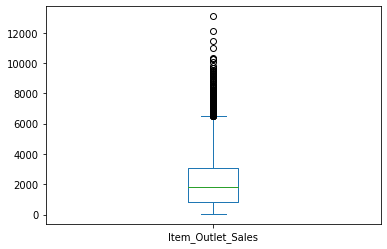

In [48]:
bigmart_df_v4.Item_Outlet_Sales.plot(kind='box')

/var/folders/46/nnxtf31j4tx1mllsphpp6gjr0000gn/T/ipykernel_90855/1408800659.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=bigmart_df_v4.Item_Outlet_Sales);


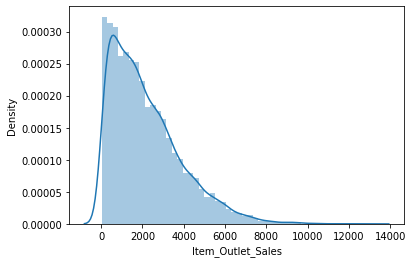

In [50]:
sns.distplot(a=bigmart_df_v4.Item_Outlet_Sales);

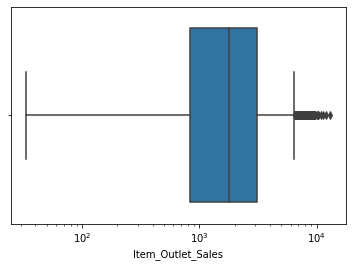

In [51]:
sns.boxplot(x=bigmart_df_v4.Item_Outlet_Sales)
plt.xscale('log')

<AxesSubplot:xlabel='Item_Outlet_Sales'>

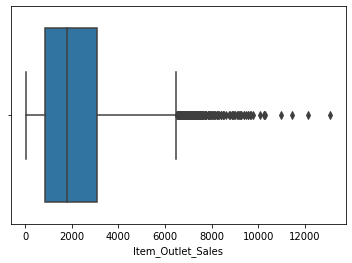

In [52]:
sns.boxplot(x=bigmart_df_v4.Item_Outlet_Sales)

#### Before Log Transformation

In [63]:
Q1 = np.percentile(bigmart_df_v4.Item_Outlet_Sales, 25)
Q3 = np.percentile(bigmart_df_v4.Item_Outlet_Sales, 75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

In [64]:
upper

6501.8699

In [57]:
bigmart_df_v4[bigmart_df_v4.Item_Outlet_Sales > upper].shape[0]/bigmart_df_v4.shape[0]

0.021823301654347062

<AxesSubplot:ylabel='Density'>

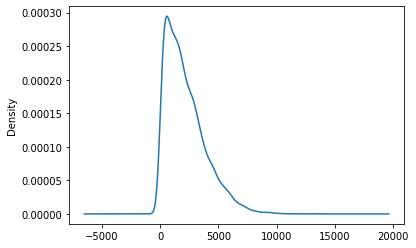

In [70]:
bigmart_df_v4.Item_Outlet_Sales.plot(kind='kde')

#### After Log Transformation

In [71]:
Q1 = np.percentile(np.log(bigmart_df_v4.Item_Outlet_Sales), 25)
Q3 = np.percentile(np.log(bigmart_df_v4.Item_Outlet_Sales), 75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

In [72]:
upper, lower

(10.00914421762982, 4.756960961558495)

In [73]:
bigmart_df_v4[np.log(bigmart_df_v4.Item_Outlet_Sales) < lower].shape[0]/bigmart_df_v4.shape[0]

0.020415346708905314

<AxesSubplot:ylabel='Density'>

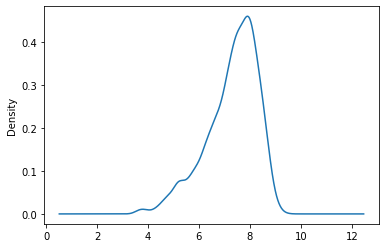

In [69]:
np.log(bigmart_df_v4.Item_Outlet_Sales).plot(kind='kde')

### Treating Outliers - Dropping

In [74]:
Q1 = np.percentile(bigmart_df_v4.Item_Outlet_Sales, 25)
Q3 = np.percentile(bigmart_df_v4.Item_Outlet_Sales, 75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

In [75]:
upper

6501.8699

In [78]:
bigmart_df_v5 = bigmart_df_v4[bigmart_df_v4.Item_Outlet_Sales < upper]

### Analyzing Item Visibility

<AxesSubplot:xlabel='Item_Visibility', ylabel='Count'>

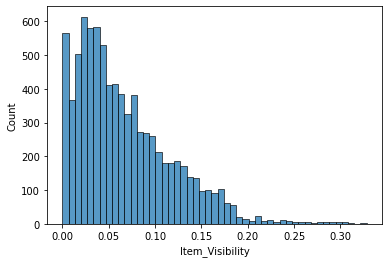

In [80]:
sns.histplot(bigmart_df_v5.Item_Visibility)

<AxesSubplot:>

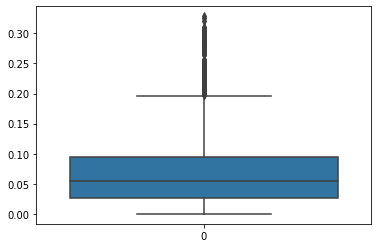

In [81]:
sns.boxplot(bigmart_df_v5.Item_Visibility)

In [85]:
bins = np.linspace(bigmart_df_v5.Item_Visibility.min(), bigmart_df_v5.Item_Visibility.max(), 6)

In [87]:
bins

array([0.        , 0.06567819, 0.13135638, 0.19703457, 0.26271276,
       0.32839095])

In [108]:
bigmart_df_v5.Item_Visibility

0       0.016047
1       0.019278
2       0.016760
3       0.000000
4       0.000000
          ...   
8518    0.056783
8519    0.046982
8520    0.035186
8521    0.145221
8522    0.044878
Name: Item_Visibility, Length: 8337, dtype: float64

In [107]:
pd.cut(bigmart_df_v5.Item_Visibility, bins=bins, labels=['NotVisible', 
                                                        'LowVisibility', 'ModerateVisibility',
                                                        'Visible', 'HighVisibility'])

0               NotVisible
1               NotVisible
2               NotVisible
3                      NaN
4                      NaN
               ...        
8518            NotVisible
8519            NotVisible
8520            NotVisible
8521    ModerateVisibility
8522            NotVisible
Name: Item_Visibility, Length: 8337, dtype: category
Categories (5, object): ['NotVisible' < 'LowVisibility' < 'ModerateVisibility' < 'Visible' < 'HighVisibility']

In [92]:
bigmart_df_v5['Item_Visibility_Bins'] = pd.cut(bigmart_df_v5.Item_Visibility, bins=bins, labels=['NotVisible', 
                                                        'LowVisibility', 'ModerateVisibility',
                                                        'Visible', 'HighVisibility'], include_lowest=True)

/var/folders/46/nnxtf31j4tx1mllsphpp6gjr0000gn/T/ipykernel_90855/4263067879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bigmart_df_v5['Item_Visibility_Bins'] = pd.cut(bigmart_df_v5.Item_Visibility, bins=bins, labels=['NotVisible', 'LowVisibility', 'ModerateVisibility',


In [93]:
bigmart_df_v5.Item_Visibility_Bins.value_counts()

NotVisible            4856
LowVisibility         2476
ModerateVisibility     864
Visible                 95
HighVisibility          46
Name: Item_Visibility_Bins, dtype: int64

### Creating OutletAge

In [96]:
bigmart_df_v5['Outlet_Age'] = 2023 - bigmart_df_v5.Outlet_Establishment_Year

/var/folders/46/nnxtf31j4tx1mllsphpp6gjr0000gn/T/ipykernel_90855/86077916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bigmart_df_v5['Outlet_Age'] = 2023 - bigmart_df_v5.Outlet_Establishment_Year


### Drop irrelevent columns

In [97]:
bigmart_df_v5.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Item_Visibility_Bins',
       'Outlet_Age'],
      dtype='object')

In [99]:
cols_to_drop = ['Item_Identifier', 'Item_Visibility', 'Outlet_Identifier', 'Outlet_Establishment_Year']
bigmart_df_v6 = bigmart_df_v5.drop(cols_to_drop, axis=1)

### Encoding Categorical Columns

In [100]:
X = bigmart_df_v6.drop('Item_Outlet_Sales', axis=1)
y = bigmart_df_v6['Item_Outlet_Sales']

In [101]:
X_dummies = pd.get_dummies(X, drop_first=True)

In [102]:
X_dummies

,Item_Weight,Item_MRP,Outlet_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,...,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Visibility_Bins_LowVisibility,Item_Visibility_Bins_ModerateVisibility,Item_Visibility_Bins_Visible,Item_Visibility_Bins_HighVisibility
0,9.300,249.8092,24,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,5.920,48.2692,14,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,17.500,141.6180,24,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,19.200,182.0950,25,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,8.930,53.8614,36,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,214.5218,36,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
8519,8.380,108.1570,21,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
8520,10.600,85.1224,19,0,0,0,0,0,0,0,...,1,1,0,1,0,0,0,0,0,0
8521,7.210,103.1332,14,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,1,0,0


### Implementing statsmodels OLS

In [104]:
import statsmodels.api as sm

X_ = sm.add_constant(X_dummies)
model = sm.OLS(y, X_)
result = model.fit()

In [105]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     347.9
Date:                Tue, 28 Nov 2023   Prob (F-statistic):               0.00
Time:                        09:51:40   Log-Likelihood:                -69441.
No. Observations:                8337   AIC:                         1.389e+05
Df Residuals:                    8306   BIC:                         1.392e+05
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                     337.1916    567.780      0.594      0.553    -775.798    1450.182
Item_Weight                                -0.6085      2.390     -0.255      0.799      -5.294       4.077
Item_MRP                                   13.8899      0.180     77.092      0.000      13.537      14.243
Outlet_Age                                -33.0849      9.168     -3.609      0.000     -51.056     -15.114
Item_Fat_Content_Regular                   50.0029     25.418      1.967      0.049       0.178      99.828
Item_Type_Breads                           -0.6211     75.594     -0.008      0.993    -148.804     147.562
Item_Type_Breakfast                       -97.2486    105.965     -0.918      0.359    -304.966     110.469
Item_Type_Canned                           28.3849     56.359      0.504      0.615     -82.093     138.863
Item_Type_Dairy                           -91.9244     56.020     -1.641      0.101    -201.738      17.889
Item_Type_Frozen Foods                    -27.3763     52.795     -0.519      0.604    -130.867      76.114
Item_Type_Fruits and Vegetables             6.9664     49.366      0.141      0.888     -89.803     103.735
Item_Type_Hard Drinks                       4.5906     80.967      0.057      0.955    -154.125     163.306
Item_Type_Health and Hygiene              -10.4672     61.010     -0.172      0.864    -130.061     109.127
Item_Type_Household                       -31.7696     53.831     -0.590      0.555    -137.291      73.752
Item_Type_Meat                             -1.3828     63.462     -0.022      0.983    -125.784     123.018
Item_Type_Others                           29.3320     87.915      0.334      0.739    -143.003     201.667
Item_Type_Seafood                         204.3603    132.830      1.539      0.124     -56.019     464.739
Item_Type_Snack Foods                     -14.2646     49.580     -0.288      0.774    -111.455      82.925
Item_Type_Soft Drinks                     -75.6193     63.090     -1.199      0.231    -199.292      48.053
Item_Type_Starchy Foods                    -4.4917     92.910     -0.048      0.961    -186.618     177.635
Outlet_Size_Medium                       -737.5373    227.535     -3.241      0.001   -1183.563    -291.512
Outlet_Size_Small                        -666.8376    222.031     -3.003      0.003   -1102.074    -231.601
Outlet_Location_Type_Tier 2              -204.6372     64.077     -3.194      0.001    -330.244     -79.031
Outlet_Location_Type_Tier 3              -373.1721    128.514     -2.904      0.004    -625.091    -121.253
Outlet_Type_Supermarket Type1            1510.9611    126.093     11.983      0.000    1263.786    1758.136
Outlet_Type_Supermarket Type2            1261.0519    115.0

<AxesSubplot:>

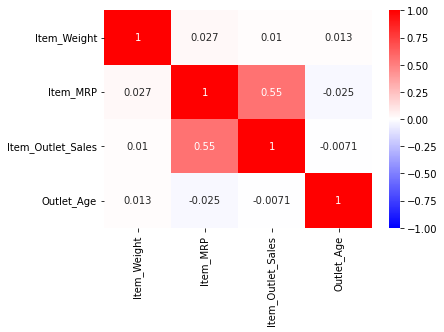

In [111]:
sns.heatmap(bigmart_df_v6.corr(), cmap='bwr', vmin=-1, vmax=1, annot=True)

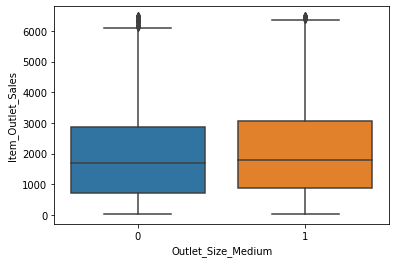

In [114]:
sns.boxplot(x=X_dummies.Outlet_Size_Medium, y=bigmart_df_v6.Item_Outlet_Sales);

### Linear model using Scikit Learn

In [115]:
train_X, test_X, train_y, test_y = train_test_split(X_dummies, y, test_size=0.3, random_state=0)

In [116]:
train_X.shape, test_X.shape, train_y.shape, test_y.shape 

((5835, 30), (2502, 30), (5835,), (2502,))

In [123]:
linear_model = LinearRegression()
linear_model.fit(train_X, train_y)


LinearRegression()

In [124]:
linear_model.coef_

array([ 1.02565617e+00,  1.38878341e+01, -4.78236971e+01,  2.17526335e+01,
        3.70249953e+01, -1.24956478e+02,  7.13835801e+01, -1.08398156e+02,
        1.37312318e+01,  2.04500725e+01, -8.15663456e+00, -4.60870385e+01,
       -2.67122763e+01, -4.97494145e+01,  2.97365109e+01,  6.46166677e+01,
       -1.28528523e+01, -7.22455030e+01, -6.51911106e+01, -1.04877240e+03,
       -9.29995678e+02, -2.85588305e+02, -5.63831737e+02,  1.34382170e+03,
        1.12303795e+03,  3.63392312e+03, -1.94249643e+01,  1.47540329e+01,
       -1.79058928e+02,  3.52036003e+01])

In [125]:
linear_model.intercept_

1166.6522797489702

In [122]:
print('Train Acc: {}'.format(linear_model.score(train_X, train_y)))
print('Test Acc: {}'.format(linear_model.score(test_X, test_y)))

Train Acc: 0.563859711713866
Test Acc: 0.5370362684972783


In [118]:
pred = linear_model.predict(test_X)

In [119]:
mean_absolute_percentage_error(test_y, pred)

1.026984167439416

In [120]:
mean_squared_error(test_y, pred)

1048024.0333326281

In [121]:
np.sqrt(mean_squared_error(test_y, pred))

1023.7304495484287

In [126]:
r2_score(test_y, pred)

0.5370362684972783